In [1]:
# =========================
# Cell 1: Imports
# =========================
import os
import re
import math
import random
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from scipy.stats import spearmanr
from sklearn.model_selection import KFold
from tqdm.auto import tqdm

from esm.models.esmc import ESMC
from esm.sdk.api import ESMProtein, LogitsConfig

In [2]:
# =========================
# Cell 2: Config
# =========================
cwd = Path.cwd()
if (cwd / "train_q1_q2_q3.csv").exists() and (cwd / "test.csv").exists():
    BASE_DIR = cwd
elif (cwd / "Active_learning" / "train_q1_q2_q3.csv").exists() and (cwd / "Active_learning" / "test.csv").exists():
    BASE_DIR = cwd / "Active_learning"
else:
    raise FileNotFoundError(
        "Could not locate data files. Run this notebook from the repo root or Active_learning/."
    )

SEQUENCE_FASTA = BASE_DIR / "sequence.fasta"
TRAIN_CSV = BASE_DIR / "train_q1_q2_q3.csv"
TEST_CSV = BASE_DIR / "test.csv"

EMB_DIR = BASE_DIR / "esm_c_embeddings_variants"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

SEED = 45
N_SPLITS = 5
N_ENSEMBLE_SEEDS = 1
SEED_POOL_MAX = 10000
BATCH_SIZE_EMB = 4
MAX_QUERY_SIZE = 100
HIDDEN_DIM = 384
BATCH_SIZE_TRAIN = 128
EPOCHS = 500
LR = 8e-5
PATIENCE = 35
WEIGHT_DECAY = 5e-5
DROPOUT = 0.2
ALPHA = 0.3
EMB_NOISE_STD = 0.002  # Max Gaussian noise std for embedding-space augmentation
EMB_NOISE_WARMUP_EPOCHS = 25  # Linearly ramp noise from 0 to EMB_NOISE_STD over these epochs
HUBER_DELTA = 0.1


def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def sample_ensemble_seeds(base_seed=SEED, n_seeds=N_ENSEMBLE_SEEDS, pool_max=SEED_POOL_MAX):
    """
    Deterministically sample random seeds from a seed pool.
    Same base_seed -> same sampled seed list (reproducible).
    """
    rng = np.random.default_rng(base_seed)
    seeds = rng.choice(np.arange(pool_max), size=n_seeds, replace=False).tolist()
    return [int(s) for s in seeds]

seed_everything(SEED)

def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()
print("Using device:", DEVICE)

Using device: cuda


In [3]:
# =========================
# Cell 3: Utilities
# =========================
AA_SET = set("ACDEFGHIKLMNPQRSTVWY")
MUT_RE = re.compile(r"^([A-Z])(\d+)([A-Z])$")

def load_fasta_sequence(fasta_path: Path) -> str:
    lines = fasta_path.read_text().strip().splitlines()
    seq_lines = [line.strip() for line in lines if not line.startswith(">")]
    sequence = "".join(seq_lines)
    if len(sequence) == 0:
        raise ValueError("FASTA sequence is empty.")
    return sequence

sequence_wt = load_fasta_sequence(SEQUENCE_FASTA)
print("WT length:", len(sequence_wt))

def parse_mutant(mutant: str):
    m = MUT_RE.match(mutant)
    if m is None:
        raise ValueError(f"Invalid mutant format: {mutant}")
    wt, pos, mt = m.group(1), int(m.group(2)), m.group(3)
    if wt not in AA_SET or mt not in AA_SET:
        raise ValueError(f"Invalid amino acid in mutant: {mutant}")
    return wt, pos, mt

def get_mutated_sequence(mutant: str, sequence_wt: str) -> str:
    wt, pos, mt = parse_mutant(mutant)

    if pos < 0 or pos >= len(sequence_wt):
        raise ValueError(f"Position out of range in mutant: {mutant}")

    actual_wt = sequence_wt[pos]
    if actual_wt != wt:
        raise ValueError(
            f"Wild-type mismatch for {mutant}: expected {wt}, sequence has {actual_wt} at position {pos}"
        )

    if wt == mt:
        raise ValueError(f"Mutation does not change residue: {mutant}")

    return sequence_wt[:pos] + mt + sequence_wt[pos + 1:]

def safe_spearman(y_true, y_pred):
    rho = spearmanr(y_true, y_pred).statistic
    if rho is None or np.isnan(rho):
        return 0.0
    return float(rho)

WT length: 656


In [4]:
# New
AA_LIST = list("ACDEFGHIKLMNPQRSTVWY")
AA_TO_IDX = {aa: i for i, aa in enumerate(AA_LIST)}

def mutant_to_features(mutant, seq_len):
    wt, pos, mt = parse_mutant(mutant)

    wt_onehot = np.zeros(len(AA_LIST), dtype=np.float32)
    mt_onehot = np.zeros(len(AA_LIST), dtype=np.float32)

    wt_onehot[AA_TO_IDX[wt]] = 1.0
    mt_onehot[AA_TO_IDX[mt]] = 1.0

    pos_feat = np.array([pos / (seq_len - 1)], dtype=np.float32)
    same_group = np.array([float(wt == mt)], dtype=np.float32)

    return np.concatenate([wt_onehot, mt_onehot, pos_feat, same_group], axis=0)

In [5]:
# =========================
# Cell 4: Load data
# =========================
df_train = pd.read_csv(TRAIN_CSV)
df_test = pd.read_csv(TEST_CSV)

required_train_cols = {"mutant", "DMS_score"}
required_test_cols = {"mutant"}

if not required_train_cols.issubset(df_train.columns):
    raise ValueError(f"train.csv must contain columns: {required_train_cols}")
if not required_test_cols.issubset(df_test.columns):
    raise ValueError(f"test.csv must contain columns: {required_test_cols}")

df_train = df_train.copy()
df_test = df_test.copy()

df_train["sequence"] = df_train["mutant"].apply(lambda x: get_mutated_sequence(x, sequence_wt))
df_test["sequence"] = df_test["mutant"].apply(lambda x: get_mutated_sequence(x, sequence_wt))

print("Train size:", len(df_train))
print("Test size:", len(df_test))

# Basic duplicate safety
if df_train["mutant"].duplicated().any():
    print("Warning: duplicate mutants found in train.csv; keeping first occurrence.")
    df_train = df_train.drop_duplicates(subset=["mutant"], keep="first").reset_index(drop=True)

if df_test["mutant"].duplicated().any():
    print("Warning: duplicate mutants found in test.csv; keeping first occurrence.")
    df_test = df_test.drop_duplicates(subset=["mutant"], keep="first").reset_index(drop=True)

Train size: 1440
Test size: 11324


In [6]:
# =========================
# Cell 5: ESM-C embeddings
# =========================
def gen_emb_from_df(df, out_dir, device, batch_size=4, model_name="esmc_600m"):
    """
    Cache one mean-pooled embedding per mutant at out_dir/{mutant}.pt
    """
    out_dir = Path(out_dir)
    out_dir.mkdir(exist_ok=True, parents=True)

    unique_df = df[["mutant", "sequence"]].drop_duplicates().reset_index(drop=True)
    items = list(unique_df.itertuples(index=False, name=None))
    print(f"Unique variants to embed: {len(items)}")

    model = ESMC.from_pretrained(model_name).to(device).eval()

    if device.type == "cuda":
        model = model.half()

    for start in tqdm(range(0, len(items), batch_size)):
        batch = items[start:start + batch_size]

        for mutant, sequence in batch:
            save_path = out_dir / f"{mutant}.pt"
            if save_path.exists():
                continue

            protein = ESMProtein(sequence=sequence)

            with torch.no_grad():
                protein_tensor = model.encode(protein)
                output = model.logits(
                    protein_tensor,
                    LogitsConfig(sequence=True, return_embeddings=True),
                )

            emb = output.embeddings
            if emb.ndim == 3:
                emb = emb[0]  # [1, L, D] -> [L, D]

            mean_emb = emb.float().mean(dim=0).detach().cpu()
            torch.save(mean_emb, save_path)

all_df = pd.concat(
    [df_train[["mutant", "sequence"]], df_test[["mutant", "sequence"]]],
    ignore_index=True
).drop_duplicates(subset=["mutant"]).reset_index(drop=True)

gen_emb_from_df(all_df, out_dir=EMB_DIR, device=DEVICE, batch_size=BATCH_SIZE_EMB)

Unique variants to embed: 12464


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

  0%|          | 0/3116 [00:00<?, ?it/s]

# =========================
# Cell 6: Dataset
# =========================
class DmsESMDataset(Dataset):
    def __init__(self, df, emb_dir, is_train=True):
        self.df = df.reset_index(drop=True).copy()
        self.emb_dir = Path(emb_dir)
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        mutant = row["mutant"]
        emb = torch.load(self.emb_dir / f"{mutant}.pt", map_location="cpu").float()

        if self.is_train:
            y = torch.tensor(float(row["DMS_score"]), dtype=torch.float32)
            return emb, y, mutant
        else:
            return emb, torch.tensor(0.0, dtype=torch.float32), mutant

In [7]:
# New
class DmsESMDataset(Dataset):
    def __init__(self, df, emb_dir, seq_len, is_train=True):
        self.df = df.reset_index(drop=True).copy()
        self.emb_dir = Path(emb_dir)
        self.seq_len = seq_len
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        mutant = row["mutant"]

        emb = torch.load(self.emb_dir / f"{mutant}.pt", map_location="cpu").float()
        mut_feat = torch.tensor(
            mutant_to_features(mutant, self.seq_len),
            dtype=torch.float32
        )

        if self.is_train:
            y = torch.tensor(float(row["DMS_score"]), dtype=torch.float32)
            return emb, mut_feat, y, mutant
        else:
            return emb, mut_feat, torch.tensor(0.0, dtype=torch.float32), mutant
        
def infer_input_dim(emb_dir, mutant_name):
    emb = torch.load(Path(emb_dir) / f"{mutant_name}.pt", map_location="cpu")
    return int(emb.shape[0])

INPUT_DIM = infer_input_dim(EMB_DIR, df_train.iloc[0]["mutant"])
print("Detected embedding dimension:", INPUT_DIM)

Detected embedding dimension: 1152


# =========================
# Cell 7: Model
# =========================

class MLPRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=512, dropout_p=0.3):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(hidden_dim, 2 * hidden_dim),
            nn.BatchNorm1d(2 * hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(2 * hidden_dim, 4 * hidden_dim),
            nn.BatchNorm1d(4 * hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(4 * hidden_dim, 8 * hidden_dim),
            nn.BatchNorm1d(8 * hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(8 * hidden_dim, 4 * hidden_dim),
            nn.BatchNorm1d(4 * hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(4 * hidden_dim, 2 * hidden_dim),
            nn.BatchNorm1d(2 * hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(2 * hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),

            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.layers(x).squeeze(-1)


In [8]:
# New
class ResidualMLPBlock(nn.Module):
    def __init__(self, dim, dropout_p=0.2):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.bn1 = nn.BatchNorm1d(dim)
        self.fc2 = nn.Linear(dim, dim)
        self.bn2 = nn.BatchNorm1d(dim)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout_p)

    def forward(self, x):
        residual = x
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.act(x)
        x = self.drop(x)

        x = self.fc2(x)
        x = self.bn2(x)
        x = x + residual
        x = self.act(x)
        x = self.drop(x)
        return x


class MLPRegressor(nn.Module):
    def __init__(self, input_dim, mut_feat_dim=42, emb_hidden=384, mut_hidden=64, fusion_hidden=256, dropout_p=0.2):
        super().__init__()

        self.emb_branch = nn.Sequential(
            nn.Linear(input_dim, emb_hidden),
            nn.BatchNorm1d(emb_hidden),
            nn.GELU(),
            nn.Dropout(dropout_p),

            nn.Linear(emb_hidden, emb_hidden),
            nn.BatchNorm1d(emb_hidden),
            nn.GELU(),
            nn.Dropout(dropout_p),
        )

        self.mut_branch = nn.Sequential(
            nn.Linear(mut_feat_dim, mut_hidden),
            nn.BatchNorm1d(mut_hidden),
            nn.GELU(),
            nn.Dropout(dropout_p),

            nn.Linear(mut_hidden, mut_hidden),
            nn.BatchNorm1d(mut_hidden),
            nn.GELU(),
            nn.Dropout(dropout_p),
        )

        fused_dim = emb_hidden + mut_hidden

        self.fusion = nn.Sequential(
            nn.Linear(fused_dim, fusion_hidden),
            nn.BatchNorm1d(fusion_hidden),
            nn.GELU(),
            nn.Dropout(dropout_p),
        )

        self.res_blocks = nn.Sequential(
            ResidualMLPBlock(fusion_hidden, dropout_p=dropout_p),
            ResidualMLPBlock(fusion_hidden, dropout_p=dropout_p),
            ResidualMLPBlock(fusion_hidden, dropout_p=dropout_p),
        )

        self.head = nn.Sequential(
            nn.Linear(fusion_hidden, fusion_hidden // 2),
            nn.BatchNorm1d(fusion_hidden // 2),
            nn.GELU(),
            nn.Dropout(dropout_p),

            nn.Linear(fusion_hidden // 2, 1),
        )

    def forward(self, emb, mut_feat):
        emb_x = self.emb_branch(emb)
        mut_x = self.mut_branch(mut_feat)

        x = torch.cat([emb_x, mut_x], dim=1)
        x = self.fusion(x)
        x = self.res_blocks(x)
        x = self.head(x)
        return x.squeeze(-1)

In [9]:
# =========================
# Cell 8: Train / evaluate helpers
# =========================
def make_loader(dataset, batch_size, shuffle):
    # Conservative defaults for Jupyter + Mac
    pin_memory = (DEVICE.type == "cuda")
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=pin_memory
    )

def train_one_fold(model, train_ds, val_ds, device, epochs=500, batch_size=256,
                   lr=1e-4, patience=30, weight_decay=1e-4, alpha=0.3,
                   emb_noise_std=0.0, emb_noise_warmup_epochs=0):
    train_loader = make_loader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = make_loader(val_ds, batch_size=batch_size, shuffle=False)

    criterion = nn.MSELoss() # nn.HuberLoss(delta=HUBER_DELTA)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=8
    )

    best_state = None
    best_val_spearman_ema = -np.inf
    patience_counter = 0
    val_spearman_ema = None

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_spearman": [],
        "val_spearman": [],
        "val_spearman_ema": [],
    }

    for epoch in range(1, epochs + 1):
        if emb_noise_std > 0.0 and emb_noise_warmup_epochs > 0:
            warmup_ratio = min(1.0, epoch / float(emb_noise_warmup_epochs))
            current_noise_std = emb_noise_std * warmup_ratio
        else:
            current_noise_std = emb_noise_std

        model.train()
        train_losses, train_preds, train_targets = [], [], []

        for emb, mut_feat, yb, _ in train_loader:
            emb = emb.to(device)
            mut_feat = mut_feat.to(device)
            yb = yb.to(device).float()

            # Embedding-space augmentation with optional warmup.
            if current_noise_std > 0.0:
                emb = emb + current_noise_std * torch.randn_like(emb)

            optimizer.zero_grad()
            preds = model(emb, mut_feat)
            loss = criterion(preds, yb)
            loss.backward()
            # nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_losses.append(loss.item())
            train_preds.append(preds.detach().cpu().numpy())
            train_targets.append(yb.detach().cpu().numpy())

        train_preds = np.concatenate(train_preds)
        train_targets = np.concatenate(train_targets)
        train_spear = safe_spearman(train_targets, train_preds)

        model.eval()
        val_losses, val_preds, val_targets = [], [], []

        with torch.no_grad():
            for emb, mut_feat, yb, _ in val_loader:
                emb = emb.to(device)
                mut_feat = mut_feat.to(device)
                yb = yb.to(device).float()

                preds = model(emb, mut_feat)
                loss = criterion(preds, yb)

                val_losses.append(loss.item())
                val_preds.append(preds.detach().cpu().numpy())
                val_targets.append(yb.detach().cpu().numpy())

        val_preds = np.concatenate(val_preds)
        val_targets = np.concatenate(val_targets)
        val_spear = safe_spearman(val_targets, val_preds)

        mean_train_loss = float(np.mean(train_losses))
        mean_val_loss = float(np.mean(val_losses))

        if val_spearman_ema is None:
            val_spearman_ema = val_spear
        else:
            val_spearman_ema = alpha * val_spear + (1 - alpha) * val_spearman_ema

        history["train_loss"].append(mean_train_loss)
        history["val_loss"].append(mean_val_loss)
        history["train_spearman"].append(train_spear)
        history["val_spearman"].append(val_spear)
        history["val_spearman_ema"].append(val_spearman_ema)

        scheduler.step(val_spearman_ema)

        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss {mean_train_loss:.4f} | Train Spearman {train_spear:.4f} | "
            f"Val Loss {mean_val_loss:.4f} | Val Spearman {val_spear:.4f} | "
            f"Val Spearman EMA {val_spearman_ema:.4f} | "
            f"Noise STD {current_noise_std:.5f} | "
            f"LR {optimizer.param_groups[0]['lr']:.2e}"
        )

        if val_spearman_ema > best_val_spearman_ema:
            best_val_spearman_ema = val_spearman_ema
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    if best_state is None:
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    return best_state, best_val_spearman_ema, history

def predict_dataset(model, dataset, device, batch_size=128):
    loader = make_loader(dataset, batch_size=batch_size, shuffle=False)
    model.eval()

    preds, mutants = [], []
    with torch.no_grad():
        for emb, mut_feat, _, batch_mutants in loader:
            emb = emb.to(device)
            mut_feat = mut_feat.to(device)
            out = model(emb, mut_feat).detach().cpu().numpy()
            preds.extend(out.tolist())
            mutants.extend(list(batch_mutants))
    return pd.DataFrame({"mutant": mutants, "prediction": preds})

In [10]:
# =========================
# Cell 9: Randomized 3-seed x 5-fold CV ensemble predictions on test
# =========================
ensemble_seeds = sample_ensemble_seeds()
print("Ensemble seeds:", ensemble_seeds)

fold_histories = []
fold_scores = []
fold_states = []

oof_pred_accum = np.zeros(len(df_train), dtype=float)
oof_count = np.zeros(len(df_train), dtype=float)

test_ds = DmsESMDataset(df_test, EMB_DIR, seq_len=len(sequence_wt), is_train=False)
test_pred_matrix = []

indices = np.arange(len(df_train))

for seed in ensemble_seeds:
    print(f"\n================ Seed {seed} ================")
    seed_everything(seed)
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)

    for fold, (train_idx, val_idx) in enumerate(kf.split(indices), start=1):
        print(f"\n========== Seed {seed} | Fold {fold}/{N_SPLITS} ==========")

        df_tr = df_train.iloc[train_idx].reset_index(drop=True)
        df_va = df_train.iloc[val_idx].reset_index(drop=True)

        train_ds = DmsESMDataset(df_tr, EMB_DIR, seq_len=len(sequence_wt), is_train=True)
        val_ds = DmsESMDataset(df_va, EMB_DIR, seq_len=len(sequence_wt), is_train=True)

        model = MLPRegressor(
            input_dim=INPUT_DIM,
            mut_feat_dim=42,
            emb_hidden=384,
            mut_hidden=64,
            fusion_hidden=256,
            dropout_p=DROPOUT
        ).to(DEVICE)

        best_state, best_val_spear, history = train_one_fold(
            model=model,
            train_ds=train_ds,
            val_ds=val_ds,
            device=DEVICE,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE_TRAIN,
            lr=LR,
            patience=PATIENCE,
            weight_decay=WEIGHT_DECAY,
            emb_noise_std=EMB_NOISE_STD,
            emb_noise_warmup_epochs=EMB_NOISE_WARMUP_EPOCHS
        )

        model.load_state_dict(best_state)
        fold_states.append(best_state)
        fold_histories.append(history)
        fold_scores.append(best_val_spear)

        # OOF predictions (averaged across seeds for each sample).
        val_pred_df = predict_dataset(model, val_ds, device=DEVICE, batch_size=BATCH_SIZE_TRAIN)
        mutant_to_pred = dict(zip(val_pred_df["mutant"], val_pred_df["prediction"]))
        fold_oof = np.array([mutant_to_pred[m] for m in df_train.iloc[val_idx]["mutant"]], dtype=float)
        oof_pred_accum[val_idx] += fold_oof
        oof_count[val_idx] += 1.0

        # Test predictions (one vector per trained model).
        test_pred_df = predict_dataset(model, test_ds, device=DEVICE, batch_size=BATCH_SIZE_TRAIN)
        test_pred_matrix.append(test_pred_df["prediction"].values)

        print(f"Seed {seed} Fold {fold} best val Spearman: {best_val_spear:.4f}")

oof_preds = np.divide(oof_pred_accum, np.maximum(oof_count, 1.0))
cv_spearman = safe_spearman(df_train["DMS_score"].values, oof_preds)
print("\nTotal models in ensemble:", len(test_pred_matrix))
print("Mean fold score:", round(float(np.mean(fold_scores)), 4))
print("OOF Spearman:", round(cv_spearman, 4))

Ensemble seeds: [9245]

================ Seed 9245 ================

========== Seed 9245 | Fold 1/5 ==========
Epoch 001 | Train Loss 0.2099 | Train Spearman 0.0497 | Val Loss 0.2208 | Val Spearman -0.0480 | Val Spearman EMA -0.0480 | Noise STD 0.00008 | LR 8.00e-05
Epoch 002 | Train Loss 0.1810 | Train Spearman 0.1889 | Val Loss 0.1380 | Val Spearman -0.0135 | Val Spearman EMA -0.0377 | Noise STD 0.00016 | LR 8.00e-05
Epoch 003 | Train Loss 0.1777 | Train Spearman 0.1675 | Val Loss 0.1177 | Val Spearman 0.0165 | Val Spearman EMA -0.0214 | Noise STD 0.00024 | LR 8.00e-05
Epoch 004 | Train Loss 0.1673 | Train Spearman 0.1699 | Val Loss 0.1160 | Val Spearman 0.0454 | Val Spearman EMA -0.0014 | Noise STD 0.00032 | LR 8.00e-05
Epoch 005 | Train Loss 0.1559 | Train Spearman 0.1987 | Val Loss 0.1152 | Val Spearman 0.0925 | Val Spearman EMA 0.0268 | Noise STD 0.00040 | LR 8.00e-05
Epoch 006 | Train Loss 0.1623 | Train Spearman 0.1831 | Val Loss 0.1132 | Val Spearman 0.1375 | Val Spearman EMA

KeyboardInterrupt: 

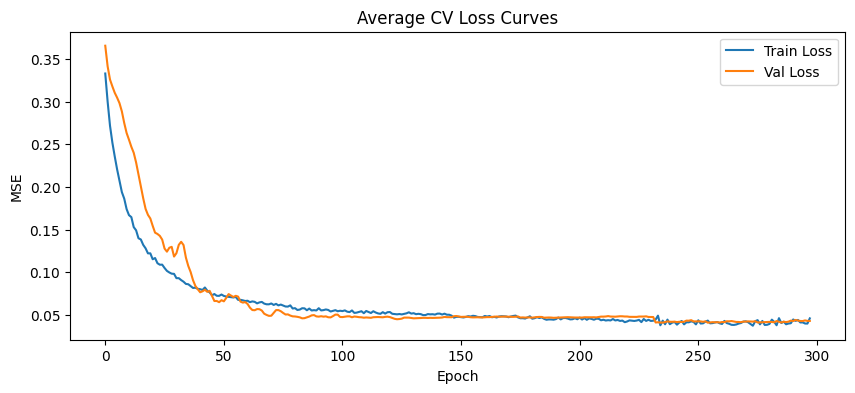

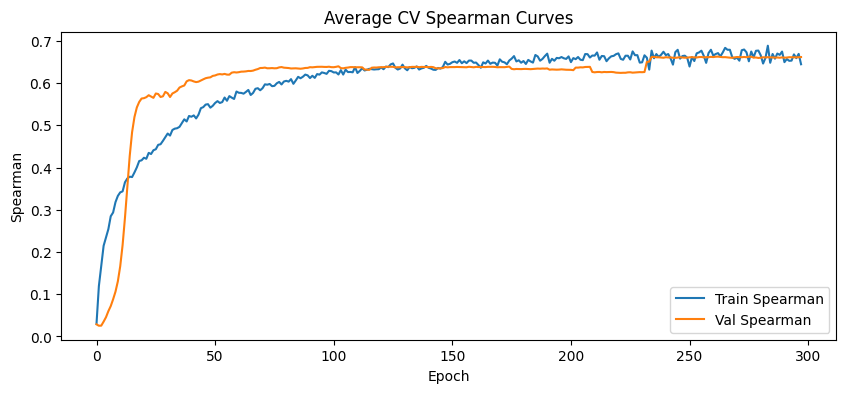

In [ ]:
# =========================
# Cell 10: Plot CV curves
# =========================
def average_histories(histories, key):
    max_len = max(len(h[key]) for h in histories)
    arr = np.full((len(histories), max_len), np.nan, dtype=float)
    for i, h in enumerate(histories):
        arr[i, :len(h[key])] = h[key]
    return np.nanmean(arr, axis=0)

avg_train_loss = average_histories(fold_histories, "train_loss")
avg_val_loss = average_histories(fold_histories, "val_loss")
avg_train_spear = average_histories(fold_histories, "train_spearman")
avg_val_spear = average_histories(fold_histories, "val_spearman")

plt.figure(figsize=(10, 4))
plt.plot(avg_train_loss, label="Train Loss")
plt.plot(avg_val_loss, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Average CV Loss Curves")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(avg_train_spear, label="Train Spearman")
plt.plot(avg_val_spear, label="Val Spearman")
plt.xlabel("Epoch")
plt.ylabel("Spearman")
plt.title("Average CV Spearman Curves")
plt.legend()
plt.show()

In [ ]:
# =========================
# Cell 11: Final predictions.csv and top10.txt
# =========================
test_pred_matrix = np.vstack(test_pred_matrix)   # [n_folds, n_test]
test_pred_mean = test_pred_matrix.mean(axis=0)
test_pred_std = test_pred_matrix.std(axis=0)

df_pred = df_test[["mutant"]].copy()
df_pred["DMS_score"] = test_pred_mean
df_pred["uncertainty"] = test_pred_std

# predictions.csv for leaderboard
predictions_path = OUTPUT_DIR / "predictions.csv"
df_pred[["mutant", "DMS_score"]].to_csv(predictions_path, index=False)

# top10.txt
top10 = (
    df_pred.sort_values("DMS_score", ascending=False)
    .head(10)[["mutant"]]
)
top10_path = OUTPUT_DIR / "top10.txt"
top10.to_csv(top10_path, index=False, header=False)

print("Saved:", predictions_path)
print("Saved:", top10_path)

display(df_pred.sort_values("DMS_score", ascending=False).head(20))

Saved: c:\Users\Cole\OneDrive\Documents\Georgia Tech\2026 Spring CSE 7850\Team Hackathon\Active_learning\outputs\predictions.csv
Saved: c:\Users\Cole\OneDrive\Documents\Georgia Tech\2026 Spring CSE 7850\Team Hackathon\Active_learning\outputs\top10.txt


,mutant,DMS_score,uncertainty
6897,E423C,0.978260,0.140031
6898,E423F,0.972239,0.151641
11037,E640A,0.968013,0.084297
974,E53A,0.963319,0.078978
2524,G139A,0.962746,0.060576
6975,E427F,0.959588,0.056875
10259,E599A,0.958725,0.073079
8667,T516V,0.958026,0.096955
636,P34N,0.956017,0.137489
6908,E423M,0.948028,0.105008


In [ ]:
# =========================
# Cell 12: Active learning query strategy
# =========================
def enrich_candidate_features(df_candidates):
    """
    Add parsed mutation info for diversity-aware selection.
    """
    df = df_candidates.copy()
    parsed = df["mutant"].apply(parse_mutant)
    df["wt"] = parsed.apply(lambda x: x[0])
    df["position"] = parsed.apply(lambda x: x[1])
    df["mt"] = parsed.apply(lambda x: x[2])
    return df

def build_query_set(
    df_candidates,
    df_labeled,
    query_size=100,
    exploit_frac=0.4,
    uncertain_frac=0.4,
    diverse_frac=0.2
):
    """
    Mix of:
      - exploit: highest predicted fitness
      - uncertain: highest ensemble std
      - diverse: spread over positions / mutation types
    """
    df_candidates = enrich_candidate_features(df_candidates)
    labeled_set = set(df_labeled["mutant"].tolist())

    # Exclude already labeled points
    pool = df_candidates[~df_candidates["mutant"].isin(labeled_set)].copy()
    pool = pool.drop_duplicates(subset=["mutant"]).reset_index(drop=True)

    n_exploit = int(query_size * exploit_frac)
    n_uncertain = int(query_size * uncertain_frac)
    n_diverse = query_size - n_exploit - n_uncertain

    selected = []

    # 1) Exploit: high predicted score
    exploit = pool.sort_values(["DMS_score", "uncertainty"], ascending=[False, False])
    for mut in exploit["mutant"]:
        if len(selected) >= n_exploit:
            break
        selected.append(mut)

    # 2) Uncertainty: high disagreement across folds
    uncertain = pool.sort_values(["uncertainty", "DMS_score"], ascending=[False, False])
    for mut in uncertain["mutant"]:
        if len(selected) >= n_exploit + n_uncertain:
            break
        if mut not in selected:
            selected.append(mut)

    # 3) Diversity: prefer new positions and mutation letters
    diverse_pool = pool[~pool["mutant"].isin(selected)].copy()
    diverse_pool = diverse_pool.sort_values(
        ["uncertainty", "DMS_score"], ascending=[False, False]
    ).reset_index(drop=True)

    used_positions = set(pool[pool["mutant"].isin(selected)]["position"].tolist())
    used_mts = set(pool[pool["mutant"].isin(selected)]["mt"].tolist())

    diversity_selected = []

    # First pass: maximize new positions and new mutant letters
    for _, row in diverse_pool.iterrows():
        if len(diversity_selected) >= n_diverse:
            break
        pos_new = row["position"] not in used_positions
        mt_new = row["mt"] not in used_mts
        if pos_new or mt_new:
            diversity_selected.append(row["mutant"])
            used_positions.add(row["position"])
            used_mts.add(row["mt"])

    # Second pass: fill any remaining slots
    if len(diversity_selected) < n_diverse:
        for mut in diverse_pool["mutant"]:
            if len(diversity_selected) >= n_diverse:
                break
            if mut not in diversity_selected:
                diversity_selected.append(mut)

    selected.extend(diversity_selected)

    # Final safety checks
    selected = selected[:query_size]
    assert len(selected) == len(set(selected)), "Duplicate mutants in query set"
    assert len(selected) <= query_size, "Too many query mutants"
    assert all(m not in labeled_set for m in selected), "Query includes labeled mutants"

    return selected

query_mutants = build_query_set(
    df_candidates=df_pred[["mutant", "DMS_score", "uncertainty"]],
    df_labeled=df_train,
    query_size=MAX_QUERY_SIZE
)

query_path = OUTPUT_DIR / "query.txt"
with open(query_path, "w") as f:
    for mut in query_mutants:
        f.write(mut + "\n")

print("Saved:", query_path)
print("Number of queries:", len(query_mutants))
print(query_mutants[:20])

Saved: c:\Users\Cole\OneDrive\Documents\Georgia Tech\2026 Spring CSE 7850\Team Hackathon\Active_learning\outputs\query.txt
Number of queries: 100
['E423F', 'E599A', 'P34N', 'T516F', 'E601N', 'E469F', 'S29V', 'E653F', 'K280Y', 'E653N', 'K280F', 'E469Y', 'E532P', 'P34V', 'E135A', 'E651F', 'E651Y', 'E422N', 'E423A', 'S29I']


## Helper functions for active learning

In [ ]:
def add_sequence_column(df, sequence_wt):
    df = df.copy()
    df["sequence"] = df["mutant"].apply(lambda x: get_mutated_sequence(x, sequence_wt))
    return df

def merge_new_query_results(df_train, new_results_path, sequence_wt):
    """
    new_results_path must contain columns: mutant, DMS_score
    """
    new_df = pd.read_csv(new_results_path)

    if not {"mutant", "DMS_score"}.issubset(new_df.columns):
        raise ValueError(f"{new_results_path} must contain columns: mutant, DMS_score")

    new_df = add_sequence_column(new_df, sequence_wt)

    merged = pd.concat(
        [
            df_train[["mutant", "DMS_score", "sequence"]],
            new_df[["mutant", "DMS_score", "sequence"]],
        ],
        ignore_index=True,
    )

    merged = merged.drop_duplicates(subset=["mutant"], keep="last").reset_index(drop=True)
    return merged, new_df

In [ ]:
def train_cv_and_predict(df_train, df_test, emb_dir, device,
                         n_splits=5, hidden_dim=512, dropout=0.25,
                         epochs=250, batch_size=128, lr=1e-4,
                         patience=25, weight_decay=1e-4, n_seeds=N_ENSEMBLE_SEEDS,
                         emb_noise_std=EMB_NOISE_STD,
                         emb_noise_warmup_epochs=EMB_NOISE_WARMUP_EPOCHS):
    """
    Retrains CV models on updated train set with randomized multi-seed ensembling.
    Returns:
      df_pred: test predictions with mean and std across all seed x fold models
      fold_scores: validation spearman of each trained model
      oof_spearman: overall out-of-fold spearman on current train set
      fold_histories: training histories
      fold_states: checkpoints for each trained model
    """
    indices = np.arange(len(df_train))
    ensemble_seeds = sample_ensemble_seeds(base_seed=SEED, n_seeds=n_seeds)
    print("Ensemble seeds:", ensemble_seeds)

    test_ds = DmsESMDataset(df_test, emb_dir, seq_len=len(sequence_wt), is_train=False)

    fold_scores = []
    fold_histories = []
    fold_states = []
    test_pred_matrix = []

    oof_pred_accum = np.zeros(len(df_train), dtype=float)
    oof_count = np.zeros(len(df_train), dtype=float)

    for seed in ensemble_seeds:
        seed_everything(seed)
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
        print(f"\n================ Seed {seed} ================")

        for fold, (train_idx, val_idx) in enumerate(kf.split(indices), start=1):
            print(f"\n========== Seed {seed} | Fold {fold}/{n_splits} ==========")

            df_tr = df_train.iloc[train_idx].reset_index(drop=True)
            df_va = df_train.iloc[val_idx].reset_index(drop=True)

            train_ds = DmsESMDataset(df_tr, emb_dir, seq_len=len(sequence_wt), is_train=True)
            val_ds = DmsESMDataset(df_va, emb_dir, seq_len=len(sequence_wt), is_train=True)

            model = MLPRegressor(
                input_dim=INPUT_DIM,
                mut_feat_dim=42,
                emb_hidden=384,
                mut_hidden=64,
                fusion_hidden=256,
                dropout_p=dropout
            ).to(device)

            best_state, best_val_spear, history = train_one_fold(
                model=model,
                train_ds=train_ds,
                val_ds=val_ds,
                device=device,
                epochs=epochs,
                batch_size=batch_size,
                lr=lr,
                patience=patience,
                weight_decay=weight_decay,
                emb_noise_std=emb_noise_std,
                emb_noise_warmup_epochs=emb_noise_warmup_epochs
            )

            model.load_state_dict(best_state)

            fold_scores.append(best_val_spear)
            fold_histories.append(history)
            fold_states.append(best_state)

            # OOF predictions (averaged across seeds for each sample).
            val_pred_df = predict_dataset(model, val_ds, device=device, batch_size=batch_size)
            mutant_to_pred = dict(zip(val_pred_df["mutant"], val_pred_df["prediction"]))
            fold_oof = np.array([mutant_to_pred[m] for m in df_train.iloc[val_idx]["mutant"]], dtype=float)
            oof_pred_accum[val_idx] += fold_oof
            oof_count[val_idx] += 1.0

            # Test predictions
            test_pred_df = predict_dataset(model, test_ds, device=device, batch_size=batch_size)
            test_pred_matrix.append(test_pred_df["prediction"].values)

            print(f"Seed {seed} Fold {fold} val Spearman: {best_val_spear:.4f}")

    oof_preds = np.divide(oof_pred_accum, np.maximum(oof_count, 1.0))
    oof_spearman = safe_spearman(df_train["DMS_score"].values, oof_preds)

    test_pred_matrix = np.vstack(test_pred_matrix)
    test_pred_mean = test_pred_matrix.mean(axis=0)
    test_pred_std = test_pred_matrix.std(axis=0)

    df_pred = df_test[["mutant"]].copy()
    df_pred["DMS_score"] = test_pred_mean
    df_pred["uncertainty"] = test_pred_std

    print("Total models in ensemble:", test_pred_matrix.shape[0])
    print("Mean validation Spearman:", round(float(np.mean(fold_scores)), 4))

    return df_pred, fold_scores, oof_spearman, fold_histories, fold_states

In [ ]:
def save_query_file(query_mutants, out_path):
    with open(out_path, "w") as f:
        for m in query_mutants:
            f.write(m + "\n")
    print(f"Saved query file: {out_path}")
    print(f"Number of mutants: {len(query_mutants)}")

In [ ]:
def save_final_outputs(df_pred, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True, parents=True)

    predictions_path = output_dir / "predictions.csv"
    top10_path = output_dir / "top10.txt"

    df_pred[["mutant", "DMS_score"]].to_csv(predictions_path, index=False)

    top10 = df_pred.sort_values("DMS_score", ascending=False).head(10)[["mutant"]]
    top10.to_csv(top10_path, index=False, header=False)

    print("Saved:", predictions_path)
    print("Saved:", top10_path)

    return predictions_path, top10_path

# After receiving the 1st query results

In [ ]:
ROUND1_RESULTS = BASE_DIR / "round1_query_results.csv"

In [ ]:
df_train, round1_new = merge_new_query_results(df_train, ROUND1_RESULTS, sequence_wt)

print("New round 1 queried points:", len(round1_new))
print("Updated train size after round 1:", len(df_train))
display(round1_new.head())

New round 1 queried points: 100
Updated train size after round 1: 1440


,mutant,DMS_score,sequence
0,N2W,0.184792,MVWEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1,L14G,0.861222,MVNEARGNSSLNPCGEGSASSGSESSKDSSRCSTPGLDPERHERLR...
2,E39A,0.865250,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPARHERLR...
3,H41A,0.685880,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERAERLR...
4,E42A,0.944965,MVNEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHARLR...


In [ ]:
gen_emb_from_df(
    round1_new[["mutant", "sequence"]],
    out_dir=EMB_DIR,
    device=DEVICE,
    batch_size=BATCH_SIZE_EMB
)

Unique variants to embed: 100


  0%|          | 0/25 [00:00<?, ?it/s]

In [ ]:
df_pred_round1, fold_scores_r1, oof_spearman_r1, histories_r1, states_r1 = train_cv_and_predict(
    df_train=df_train,
    df_test=df_test,
    emb_dir=EMB_DIR,
    device=DEVICE,
    n_splits=N_SPLITS,
    hidden_dim=HIDDEN_DIM,
    dropout=DROPOUT,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE_TRAIN,
    lr=LR,
    patience=PATIENCE,
    weight_decay=WEIGHT_DECAY
)

print("Round 1 fold Spearman scores:", np.round(fold_scores_r1, 4))
print("Round 1 OOF Spearman:", round(oof_spearman_r1, 4))
display(df_pred_round1.sort_values("DMS_score", ascending=False).head(20))

Ensemble seeds: [6545, 892, 7738]

================ Seed 6545 ================

========== Seed 6545 | Fold 1/5 ==========
Epoch 001 | Train Loss 0.5439 | Train Spearman 0.0098 | Val Loss 0.5212 | Val Spearman 0.2002 | Val Spearman EMA 0.2002 | LR 1.00e-04
Epoch 002 | Train Loss 0.5075 | Train Spearman 0.0517 | Val Loss 0.5426 | Val Spearman 0.1739 | Val Spearman EMA 0.1923 | LR 1.00e-04
Epoch 003 | Train Loss 0.4801 | Train Spearman 0.0047 | Val Loss 0.5639 | Val Spearman 0.1355 | Val Spearman EMA 0.1753 | LR 1.00e-04
Epoch 004 | Train Loss 0.4622 | Train Spearman 0.0463 | Val Loss 0.5643 | Val Spearman 0.1081 | Val Spearman EMA 0.1551 | LR 1.00e-04
Epoch 005 | Train Loss 0.4332 | Train Spearman 0.0149 | Val Loss 0.5524 | Val Spearman 0.1006 | Val Spearman EMA 0.1388 | LR 1.00e-04
Epoch 006 | Train Loss 0.4129 | Train Spearman 0.0396 | Val Loss 0.5443 | Val Spearman 0.0987 | Val Spearman EMA 0.1267 | LR 1.00e-04
Epoch 007 | Train Loss 0.3870 | Train Spearman 0.0603 | Val Loss 0.5377 |

KeyboardInterrupt: 

In [ ]:
round1_predictions_path = OUTPUT_DIR / "predictions_round1.csv"
round1_top10_path = OUTPUT_DIR / "top10_round1.txt"

df_pred_round1[["mutant", "DMS_score"]].to_csv(round1_predictions_path, index=False)

df_pred_round1.sort_values("DMS_score", ascending=False).head(10)[["mutant"]].to_csv(
    round1_top10_path, index=False, header=False
)

print("Saved:", round1_predictions_path)
print("Saved:", round1_top10_path)

display(df_pred_round1.sort_values("DMS_score", ascending=False).head(20))

Saved: /Users/adelshad3/Desktop/Hackathon/Active Learning/outputs/predictions_round1.csv
Saved: /Users/adelshad3/Desktop/Hackathon/Active Learning/outputs/top10_round1.txt


,mutant,DMS_score,uncertainty
7136,V435K,0.656482,0.195415
213,P12G,0.635569,0.200486
4636,K280V,0.619880,0.210942
3391,K198A,0.619793,0.142606
10092,I591R,0.618162,0.250306
4653,K280L,0.614778,0.216866
77,R5A,0.606641,0.211872
280,E15N,0.603833,0.215723
7130,V435R,0.603168,0.175195
4108,T243R,0.601809,0.207009


In [ ]:
query_round2 = build_query_set(
    df_candidates=df_pred_round1[["mutant", "DMS_score", "uncertainty"]],
    df_labeled=df_train,
    query_size=100,
    exploit_frac=0.20,
    uncertain_frac=0.50,
    diverse_frac=0.30
)

save_query_file(query_round2, OUTPUT_DIR / "query_round2.txt")

Saved query file: /Users/adelshad3/Desktop/Hackathon/Active Learning/outputs/query_round2.txt
Number of mutants: 100


# After receiving the second query results

In [ ]:
ROUND2_RESULTS = BASE_DIR / "round2_query_results.csv"

In [ ]:
df_train, round2_new = merge_new_query_results(df_train, ROUND2_RESULTS, sequence_wt)

print("New round 2 queried points:", len(round2_new))
print("Updated train size after round 2:", len(df_train))
display(round2_new.head())

New round 2 queried points: 100
Updated train size after round 2: 1340


,mutant,DMS_score,sequence
0,E3C,0.745692,MVNCARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1,A4M,0.796622,MVNEMRGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
2,A4V,0.927950,MVNEVRGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
3,A4C,0.733380,MVNECRGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
4,R5K,0.730065,MVNEAKGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...


In [ ]:
gen_emb_from_df(
    round2_new[["mutant", "sequence"]],
    out_dir=EMB_DIR,
    device=DEVICE,
    batch_size=BATCH_SIZE_EMB
)

Unique variants to embed: 100


  0%|          | 0/25 [00:00<?, ?it/s]

In [ ]:
df_pred_round2, fold_scores_r2, oof_spearman_r2, histories_r2, states_r2 = train_cv_and_predict(
    df_train=df_train,
    df_test=df_test,
    emb_dir=EMB_DIR,
    device=DEVICE,
    n_splits=N_SPLITS,
    hidden_dim= 384,
    dropout= 0.2,
    epochs=EPOCHS,
    batch_size=128,
    lr= 8e-5,
    patience=PATIENCE,
    weight_decay= 5e-5
)

#SEED = 42
#N_SPLITS = 5
#BATCH_SIZE_EMB = 4    
#MAX_QUERY_SIZE = 100
#BATCH_SIZE_TRAIN = 256
#EPOCHS = 500
#PATIENCE = 30
#WEIGHT_DECAY = 1e-4
#DROPOUT = 0.3
#HIDDEN_DIM = 512
#LR = 1e-4
#ALPHA = 0.3

print("Round 2 fold Spearman scores:", np.round(fold_scores_r2, 4))
print("Round 2 OOF Spearman:", round(oof_spearman_r2, 4))
display(df_pred_round2.sort_values("DMS_score", ascending=False).head(20))


========== Fold 1/5 ==========
Epoch 001 | Train Loss 0.2442 | Train Spearman 0.0356 | Val Loss 0.2688 | Val Spearman -0.1146 | Val Spearman EMA -0.1146 | LR 8.00e-05
Epoch 002 | Train Loss 0.2155 | Train Spearman 0.1117 | Val Loss 0.2358 | Val Spearman -0.0502 | Val Spearman EMA -0.0953 | LR 8.00e-05
Epoch 003 | Train Loss 0.1805 | Train Spearman 0.1685 | Val Loss 0.2072 | Val Spearman 0.0516 | Val Spearman EMA -0.0512 | LR 8.00e-05
Epoch 004 | Train Loss 0.1945 | Train Spearman 0.0930 | Val Loss 0.1873 | Val Spearman 0.0897 | Val Spearman EMA -0.0089 | LR 8.00e-05
Epoch 005 | Train Loss 0.1568 | Train Spearman 0.2365 | Val Loss 0.1802 | Val Spearman 0.1162 | Val Spearman EMA 0.0286 | LR 8.00e-05
Epoch 006 | Train Loss 0.1466 | Train Spearman 0.2237 | Val Loss 0.1767 | Val Spearman 0.1238 | Val Spearman EMA 0.0572 | LR 8.00e-05
Epoch 007 | Train Loss 0.1266 | Train Spearman 0.2801 | Val Loss 0.1701 | Val Spearman 0.1671 | Val Spearman EMA 0.0901 | LR 8.00e-05
Epoch 008 | Train Loss 0

,mutant,DMS_score,uncertainty
8667,T516V,0.989802,0.059719
8678,T516I,0.982598,0.037440
7268,P442L,0.979572,0.024959
11228,R650T,0.965440,0.030866
3179,H180F,0.964060,0.024353
8664,T516L,0.960316,0.020640
6982,E427V,0.959701,0.027574
88,R5N,0.956702,0.038960
7258,P442I,0.952208,0.041275
6979,E427I,0.949794,0.046943


In [ ]:
round2_predictions_path = OUTPUT_DIR / "predictions_round2.csv"
round2_top10_path = OUTPUT_DIR / "top10_round2.txt"

df_pred_round2[["mutant", "DMS_score"]].to_csv(round2_predictions_path, index=False)

df_pred_round2.sort_values("DMS_score", ascending=False).head(10)[["mutant"]].to_csv(
    round2_top10_path, index=False, header=False
)

print("Saved:", round2_predictions_path)
print("Saved:", round2_top10_path)

display(df_pred_round2.sort_values("DMS_score", ascending=False).head(20))

Saved: /Users/adelshad3/Desktop/Hackathon/Active Learning/outputs/predictions_round2.csv
Saved: /Users/adelshad3/Desktop/Hackathon/Active Learning/outputs/top10_round2.txt


,mutant,DMS_score,uncertainty
8667,T516V,0.989802,0.059719
8678,T516I,0.982598,0.037440
7268,P442L,0.979572,0.024959
11228,R650T,0.965440,0.030866
3179,H180F,0.964060,0.024353
8664,T516L,0.960316,0.020640
6982,E427V,0.959701,0.027574
88,R5N,0.956702,0.038960
7258,P442I,0.952208,0.041275
6979,E427I,0.949794,0.046943


In [ ]:
query_round3 = build_query_set(
    df_candidates=df_pred_round2[["mutant", "DMS_score", "uncertainty"]],
    df_labeled=df_train,
    query_size=100,
    exploit_frac=0.35,
    uncertain_frac=0.35,
    diverse_frac=0.30
)

save_query_file(query_round3, OUTPUT_DIR / "query_round3.txt")

Saved query file: /Users/adelshad3/Desktop/Hackathon/Active Learning/outputs/query_round3.txt
Number of mutants: 100


# After receiving the 3rd query results

In [ ]:
ROUND3_RESULTS = BASE_DIR / "round3_query_results.csv"

In [ ]:
df_train, round3_new = merge_new_query_results(df_train, ROUND3_RESULTS, sequence_wt)

print("New round 3 queried points:", len(round3_new))
print("Updated train size after round 3:", len(df_train))
display(round3_new.head())

New round 3 queried points: 100
Updated train size after round 3: 1440


,mutant,DMS_score,sequence
0,V1A,0.928892,MANEARGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
1,R5D,0.700522,MVNEADGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
2,R5N,0.498950,MVNEANGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
3,R5V,0.658180,MVNEAVGNSSLNPCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...
4,P12N,0.972665,MVNEARGNSSLNNCLEGSASSGSESSKDSSRCSTPGLDPERHERLR...


In [ ]:
gen_emb_from_df(
    round3_new[["mutant", "sequence"]],
    out_dir=EMB_DIR,
    device=DEVICE,
    batch_size=BATCH_SIZE_EMB
)

Unique variants to embed: 100


  0%|          | 0/25 [00:00<?, ?it/s]

In [ ]:
df_pred_final, fold_scores_final, oof_spearman_final, histories_final, states_final = train_cv_and_predict(
    df_train=df_train,
    df_test=df_test,
    emb_dir=EMB_DIR,
    device=DEVICE,
    n_splits=N_SPLITS,
    hidden_dim= 128, #256,
    dropout= 0.3,
    epochs=EPOCHS,
    batch_size= 64, #128,
    lr= 8e-5,
    patience=40,
    weight_decay= 5e-5
)

print("Final fold Spearman scores:", np.round(fold_scores_final, 4))
print("Final OOF Spearman:", round(oof_spearman_final, 4))
display(df_pred_final.sort_values("DMS_score", ascending=False).head(20))


========== Fold 1/5 ==========
Epoch 001 | Train Loss 0.3750 | Train Spearman 0.0251 | Val Loss 0.3074 | Val Spearman 0.0761 | Val Spearman EMA 0.0761 | LR 8.00e-05
Epoch 002 | Train Loss 0.3436 | Train Spearman 0.0325 | Val Loss 0.2431 | Val Spearman 0.0953 | Val Spearman EMA 0.0818 | LR 8.00e-05
Epoch 003 | Train Loss 0.2940 | Train Spearman 0.1008 | Val Loss 0.2142 | Val Spearman 0.1142 | Val Spearman EMA 0.0916 | LR 8.00e-05
Epoch 004 | Train Loss 0.2516 | Train Spearman 0.1068 | Val Loss 0.1722 | Val Spearman 0.2434 | Val Spearman EMA 0.1371 | LR 8.00e-05
Epoch 005 | Train Loss 0.2531 | Train Spearman 0.1549 | Val Loss 0.1594 | Val Spearman 0.4032 | Val Spearman EMA 0.2169 | LR 8.00e-05
Epoch 006 | Train Loss 0.2184 | Train Spearman 0.2058 | Val Loss 0.1121 | Val Spearman 0.4735 | Val Spearman EMA 0.2939 | LR 8.00e-05
Epoch 007 | Train Loss 0.2052 | Train Spearman 0.2122 | Val Loss 0.1627 | Val Spearman 0.4363 | Val Spearman EMA 0.3366 | LR 8.00e-05
Epoch 008 | Train Loss 0.1934 

,mutant,DMS_score,uncertainty
533,S29V,0.889078,0.027364
540,S29F,0.887849,0.023216
7648,E462L,0.887780,0.014905
7644,E462F,0.886693,0.015939
650,G35W,0.885923,0.016679
7655,E462I,0.884581,0.015064
584,C31F,0.884309,0.019450
550,S29Y,0.883853,0.021902
630,P34F,0.880729,0.033398
541,S29I,0.879641,0.019036


In [ ]:
round3_predictions_path = OUTPUT_DIR / "predictions_round3.csv"
round3_top10_path = OUTPUT_DIR / "top10_round3.txt"

df_pred_final[["mutant", "DMS_score"]].to_csv(round3_predictions_path, index=False)

df_pred_final.sort_values("DMS_score", ascending=False).head(10)[["mutant"]].to_csv(
    round3_top10_path, index=False, header=False
)

print("Saved:", round3_predictions_path)
print("Saved:", round3_top10_path)

display(df_pred_final.sort_values("DMS_score", ascending=False).head(20))

Saved: /Users/adelshad3/Desktop/Hackathon/Active Learning/outputs/predictions_round3.csv
Saved: /Users/adelshad3/Desktop/Hackathon/Active Learning/outputs/top10_round3.txt


,mutant,DMS_score,uncertainty
533,S29V,0.889078,0.027364
540,S29F,0.887849,0.023216
7648,E462L,0.887780,0.014905
7644,E462F,0.886693,0.015939
650,G35W,0.885923,0.016679
7655,E462I,0.884581,0.015064
584,C31F,0.884309,0.019450
550,S29Y,0.883853,0.021902
630,P34F,0.880729,0.033398
541,S29I,0.879641,0.019036


In [ ]:
predictions_path, top10_path = save_final_outputs(df_pred_final, OUTPUT_DIR)

top10_df = df_pred_final.sort_values("DMS_score", ascending=False).head(10)
display(top10_df)